In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
drop_col= ["life_expectancy","adult_mortality","bmi","polio","diphtheria","thinness__1_19_years","thinness_5_9_years"]

imp_col= ["alcohol", "hepatitis_b", "total_expenditure", "gdp", "population", "schooling", "income_composition_of_resources"]

In [3]:
df = (pd.read_csv("Life Expectancy Data.csv")
      .rename(columns= lambda col:col.strip().lower().replace(" ","_").replace("-","_")) #<<<< for naming consistency 
      .dropna(subset= drop_col, how="any")         #<<<< Drop rows with null values </= 5 percent of the total rows
      


      )
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
## Data Cleaning:Perform the 5-step inspection ritual to understand the data 
df.shape
##df.info()
##df.isnull().sum()
##df.dtypes

(2888, 22)

In [5]:
## Find the Total number of Missing values per column
total_rows = df.shape[0]
null_rows = df.isnull().sum()


In [6]:
## Find the percentage of Missing values 
per_null = null_rows / total_rows*100
##print(f"Sum of Missing values :\n {null_rows}")
print(f"Percentage of Missing values : {per_null}")



Percentage of Missing values : country                             0.000000
year                                0.000000
status                              0.000000
life_expectancy                     0.000000
adult_mortality                     0.000000
infant_deaths                       0.000000
alcohol                             6.059557
percentage_expenditure              0.000000
hepatitis_b                        18.178670
measles                             0.000000
bmi                                 0.000000
under_five_deaths                   0.000000
polio                               0.000000
total_expenditure                   7.340720
diphtheria                          0.000000
hiv/aids                            0.000000
gdp                                15.062327
population                         22.299169
thinness__1_19_years                0.000000
thinness_5_9_years                  0.000000
income_composition_of_resources     5.540166
schooling               

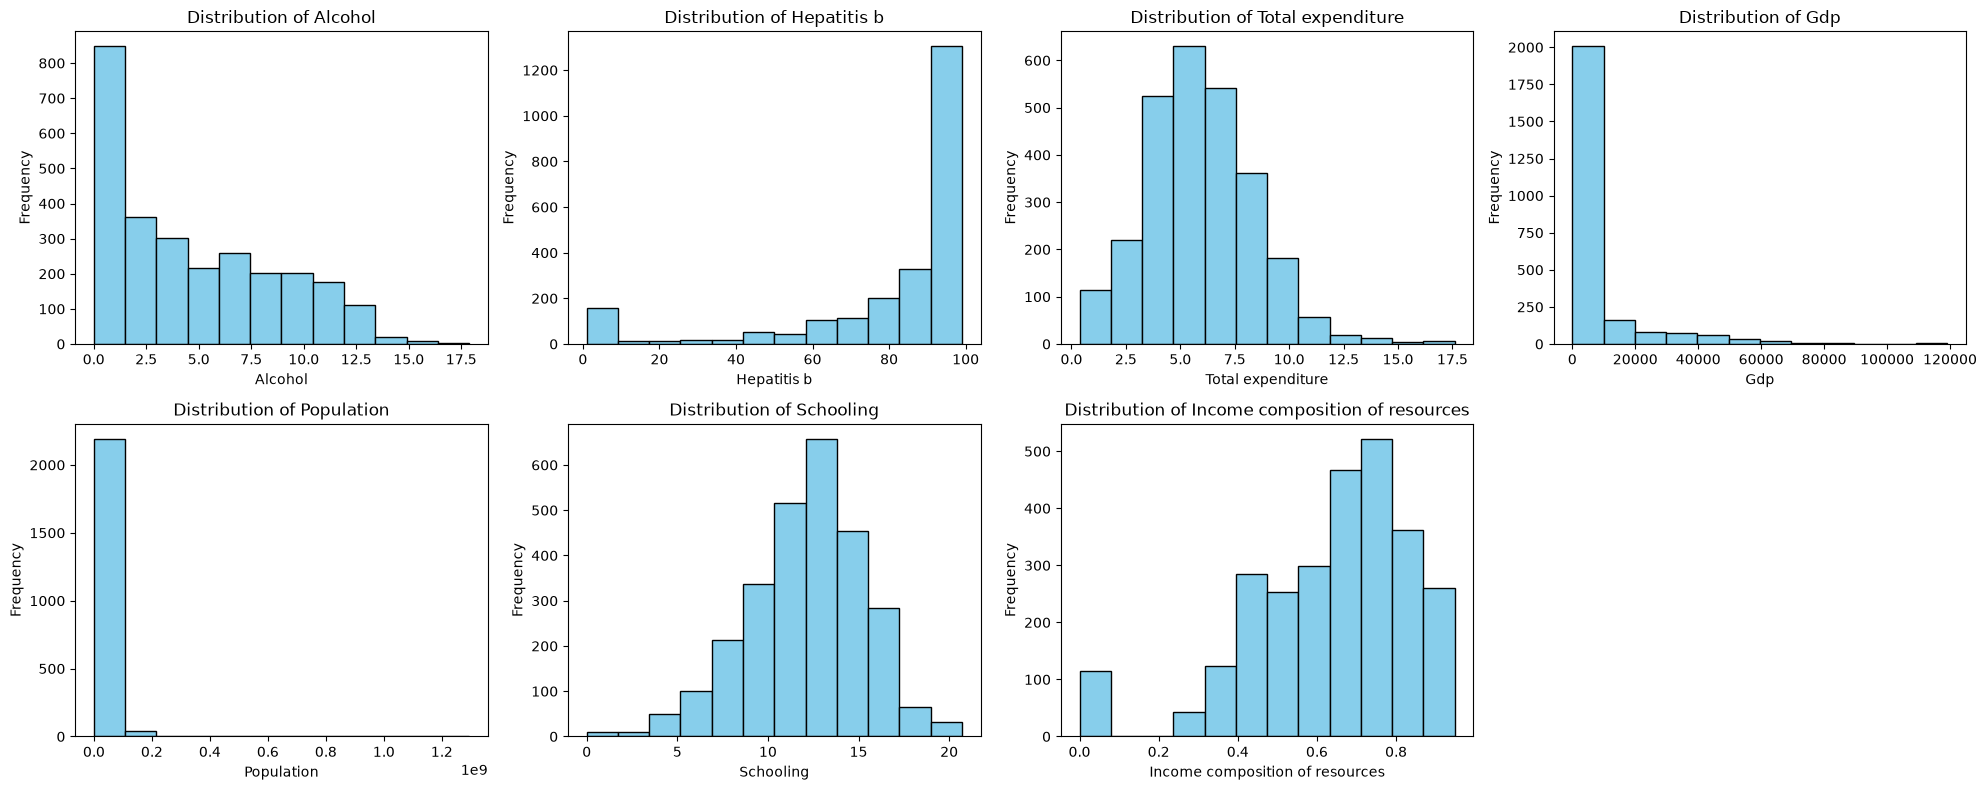

In [7]:
fig,axes=plt.subplots(figsize=(20,8), nrows=2, ncols=4)

axes=axes.flatten()
for i, col in enumerate(imp_col):
    axes[i].hist(df[col],bins=12, color="skyblue", edgecolor="black")
    axes[i].set_title(f'Distribution of {col.capitalize().replace("_"," ")}') 
    axes[i].set_xlabel(col.capitalize().replace("_"," "))
    axes[i].set_ylabel("Frequency")

for j in range(len(imp_col),len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 


In [8]:
df.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
count,2888.000000,2888.000000,2888.000000,2888.000000,2713.000000,2888.000000,2363.000000,2888.000000,2888.000000,2888.000000,2888.000000,2676.000000,2888.000000,2888.000000,2453.000000,2.244000e+03,2888.000000,2888.000000,2728.000000,2728.000000
mean,2007.515235,69.349377,163.357341,30.314751,4.643830,749.475611,81.022006,2442.514543,38.221087,41.985803,82.672091,5.931626,82.437673,1.749792,7576.831245,1.283534e+07,4.850589,4.881337,0.632543,12.116312
std,4.606938,9.495441,124.018934,118.891670,4.053529,2003.090073,24.976423,11561.322467,19.962630,161.743345,23.333655,2.482684,23.648907,5.116551,14356.369723,6.155374e+07,4.421403,4.510414,0.206210,3.197199
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.475000,73.000000,0.000000,0.930000,5.049462,77.000000,0.000000,19.300000,0.000000,78.000000,4.270000,78.000000,0.100000,464.184650,1.939068e+05,1.600000,1.500000,0.500000,10.200000
50%,2008.000000,72.200000,143.000000,3.000000,3.810000,67.687008,92.000000,17.000000,43.250000,4.000000,93.000000,5.750000,93.000000,0.100000,1812.288374,1.383743e+06,3.350000,3.400000,0.679500,12.400000
75%,2012.000000,75.800000,225.000000,21.000000,7.800000,454.422430,97.000000,352.250000,56.100000,26.000000,97.000000,7.470000,97.000000,0.800000,6256.559260,7.399592e+06,7.200000,7.200000,0.781000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,77.600000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [9]:
mean_col= ["alcohol","total_expenditure", "gdp", "population", "income_composition_of_resources"]
median_col= ["hepatitis_b","schooling"]



In [14]:
for col in mean_col:
    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)

for col in median_col:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 2888 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2888 non-null   str    
 1   year                             2888 non-null   int64  
 2   status                           2888 non-null   str    
 3   life_expectancy                  2888 non-null   float64
 4   adult_mortality                  2888 non-null   float64
 5   infant_deaths                    2888 non-null   int64  
 6   alcohol                          2888 non-null   float64
 7   percentage_expenditure           2888 non-null   float64
 8   hepatitis_b                      2888 non-null   float64
 9   measles                          2888 non-null   int64  
 10  bmi                              2888 non-null   float64
 11  under_five_deaths                2888 non-null   int64  
 12  polio                            288